# T60 AUV 最新精度 Policy 可视化

评估当前 `t60_trajectory_precision_v14.json` 对应的最新 `t60_precision_v14` 运行，并固定使用其中最后稳定的 `model_350.pt`。该 policy 以 25 Hz 更新，使用无注入噪声且确定性延迟 50 ms 的融合状态、roll/pitch/yaw 分轴且精度半宽 2.5° 的 `precision_v9` reward、201 维 `mlp_history_8` Actor、固定 `3e-4` 学习率 PPO、`0.010` 原始动作幅值代价与 `2.5` 确定性 Actor 均值曲率项、完整 6×6 CFD 水动力，以及固定准确刚体参数、分阶段水动力系数 DR、逐台推进器增益失配和全体推进器共同弱化 0–15%。目标姿态始终保持 `roll=pitch=0`，仅让 yaw 跟随水平速度方向；训练仅使用三轴纯正弦与横向/垂向前进正弦，Lissajous 在这里作为未参与训练的组合泛化评估。

Isaac Sim 中的本次评估轨迹为包络 **5 × 3 × 1 m**、目标线速度 **0.25 m/s** 的空间 Lissajous。评估始终启用安全边界，并分别报告全程与稳态误差。

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
from IPython.display import display
from simulation.domain_randomization import load_domain_randomization_spec_json
from simulation.training.campaign import configure_plots, run_command
from simulation.training.evaluation.metrics import (
    collect_summary_df, load_eval_log, plot_eval_detail, quick_numeric_report,
)
from simulation.training.recipe import (
    ExperimentSpec, load_training_recipe, run_input_paths,
)

configure_plots()
ISAACLAB_ROOT = Path.home() / 'IsaacLab'
RLPOLICY_ROOT = REPO_ROOT / 'simulation/rlpolicy'
RECIPE_PATH = REPO_ROOT / 'simulation/training/recipes/t60_trajectory_precision_v14.json'
RUN_NAME = 't60_precision_v14'
RECIPE = load_training_recipe(RECIPE_PATH)
SPEC = ExperimentSpec(
    isaaclab_root=ISAACLAB_ROOT,
    rlpolicy_root=RLPOLICY_ROOT,
    mlp_architecture=RECIPE.mlp_architecture,
)
CHECKPOINT = 'model_350.pt'
CHECKPOINT_PATH = max(
    SPEC.logs_root.glob(f'*_{RUN_NAME}/{CHECKPOINT}'),
    key=lambda checkpoint_path: checkpoint_path.stat().st_mtime,
)
POLICY_RUN_DIR = CHECKPOINT_PATH.parent
ACTIVE_RUN = POLICY_RUN_DIR.name
RUN_INPUTS = run_input_paths(POLICY_RUN_DIR)
RUN_RECIPE = load_training_recipe(RUN_INPUTS.recipe)
RUN_DR = load_domain_randomization_spec_json(RUN_INPUTS.domain_randomization)

TRAJECTORY = 'lissajous'
TRAJECTORY_MAX_SPEED_MPS = 0.25
TRAJECTORY_SIZE_X_M = 5.0
TRAJECTORY_SIZE_Y_M = 3.0
TRAJECTORY_SIZE_Z_M = 1.0
TRAJECTORY_AMP_X_M = TRAJECTORY_SIZE_X_M / 2.0
TRAJECTORY_AMP_Y_M = TRAJECTORY_SIZE_Y_M / 2.0
TRAJECTORY_AMP_Z_M = TRAJECTORY_SIZE_Z_M / 2.0
DURATION_S = 140.0
EVALUATION_LABEL = (
    f'{Path(CHECKPOINT).stem}_5x3x1_lissajous_vmax_{TRAJECTORY_MAX_SPEED_MPS:.2f}'
    .replace('.', 'p')
)

print(f'run: {POLICY_RUN_DIR}')
print(f'checkpoint: {CHECKPOINT}')
print(f'recipe: {RUN_RECIPE.name} / reward: {RUN_RECIPE.reward_profile}')
print(f'DR: {RUN_DR.name} / schema: {RUN_DR.schema_version}')
print(f'trajectory: {TRAJECTORY} with max speed {TRAJECTORY_MAX_SPEED_MPS:.2f} m/s')
print(f'curve envelope: {TRAJECTORY_SIZE_X_M:.1f} × {TRAJECTORY_SIZE_Y_M:.1f} × {TRAJECTORY_SIZE_Z_M:.1f} m')


run: /home/jining_yang/isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-28_01-44-06_t60_precision_v11
checkpoint: model_499.pt
recipe: t60-trajectory-precision-v11 / reward: precision_v6
DR: auv-open-water-openfoam-hydrodynamics-dr-v8--t60-trajectory-precision-v11 / schema: 8
trajectory: lissajous with max speed 0.14 m/s
curve envelope: 5.0 × 3.0 × 1.0 m


## 启动 Isaac Sim 实时可视化

蓝线为目标，橙线为真实轨迹。140 秒结束后窗口自动关闭。

In [2]:
VISUALIZATION_COMMAND = [
    './isaaclab.sh', '-p', SPEC.eval_script,
    '--task', SPEC.task_name,
    '--checkpoint', str(CHECKPOINT_PATH),
    '--trajectory', TRAJECTORY,
    '--trajectory_speed', str(TRAJECTORY_MAX_SPEED_MPS),
    '--trajectory_amp_x', str(TRAJECTORY_AMP_X_M),
    '--trajectory_amp_y', str(TRAJECTORY_AMP_Y_M),
    '--trajectory_amp_z', str(TRAJECTORY_AMP_Z_M),
    '--duration', str(DURATION_S),
    '--num_envs', '1',
    '--seed', '42',
    '--evaluation_label', EVALUATION_LABEL,
    '--align_initial_target',
]
run_command(
    VISUALIZATION_COMMAND,
    cwd=ISAACLAB_ROOT,
    execute=True,
    label=f'{Path(CHECKPOINT).stem.upper()} LIVE VISUALIZATION',
)


[MODEL_499 LIVE VISUALIZATION]
./isaaclab.sh -p source/isaaclab_tasks/isaaclab_tasks/direct/isaac-auv-env/simulation/training/evaluation/cli.py --task Isaac-AUV-Traj-Direct-v1 --checkpoint ../isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-28_01-44-06_t60_precision_v11/model_499.pt --trajectory lissajous --trajectory_speed 0.14 --trajectory_amp_x 2.5 --trajectory_amp_y 1.5 --trajectory_amp_z 0.5 --duration 140.0 --num_envs 1 --seed 42 --evaluation_label model_499_5x3x1_lissajous_vmax_0p14 --align_initial_target

H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H   
[INFO] Using python from: /home/jining_yang/miniconda3/envs/env_isaaclab/bin/python
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: /home/jining_yang/IsaacLab/apps/isaaclab.python.kit
Loading user config located at: '/home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/isaacsim/kit

0

## 跟踪结果

,checkpoint_name,position_rmse,steady_position_rmse,steady_position_error_p95,steady_position_bias_norm_m,steady_position_x_rmse_m,steady_position_y_rmse_m,steady_position_z_rmse_m,steady_cross_track_position_error_rmse_m,steady_attitude_error_rmse_deg,steady_mean_nose_to_target_heading_angle_deg,mean_thruster_wrench_force_norm_n,minimum_vehicle_boundary_clearance_m,mean_reward_per_step
0,model_499.pt,0.023707,0.023922,0.044378,0.006858,0.011559,0.0195,0.007641,0.020852,1.013012,0.652395,2.391136,0.495321,0.898693


,trajectory,evaluated_checkpoints,best_position_rmse,median_position_rmse,best_velocity_rmse
0,lissajous,1,0.023707,0.023707,0.005041


loaded 3500 time-aligned rows from /home/jining_yang/isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-28_01-44-06_t60_precision_v11/evaluation/model_499_model_499_5x3x1_lissajous_vmax_0p14_trajectory_eval/logs.csv
Saved: /home/jining_yang/isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-28_01-44-06_t60_precision_v11/evaluation/model_499_model_499_5x3x1_lissajous_vmax_0p14_trajectory_eval/tracking_eval_env0.png


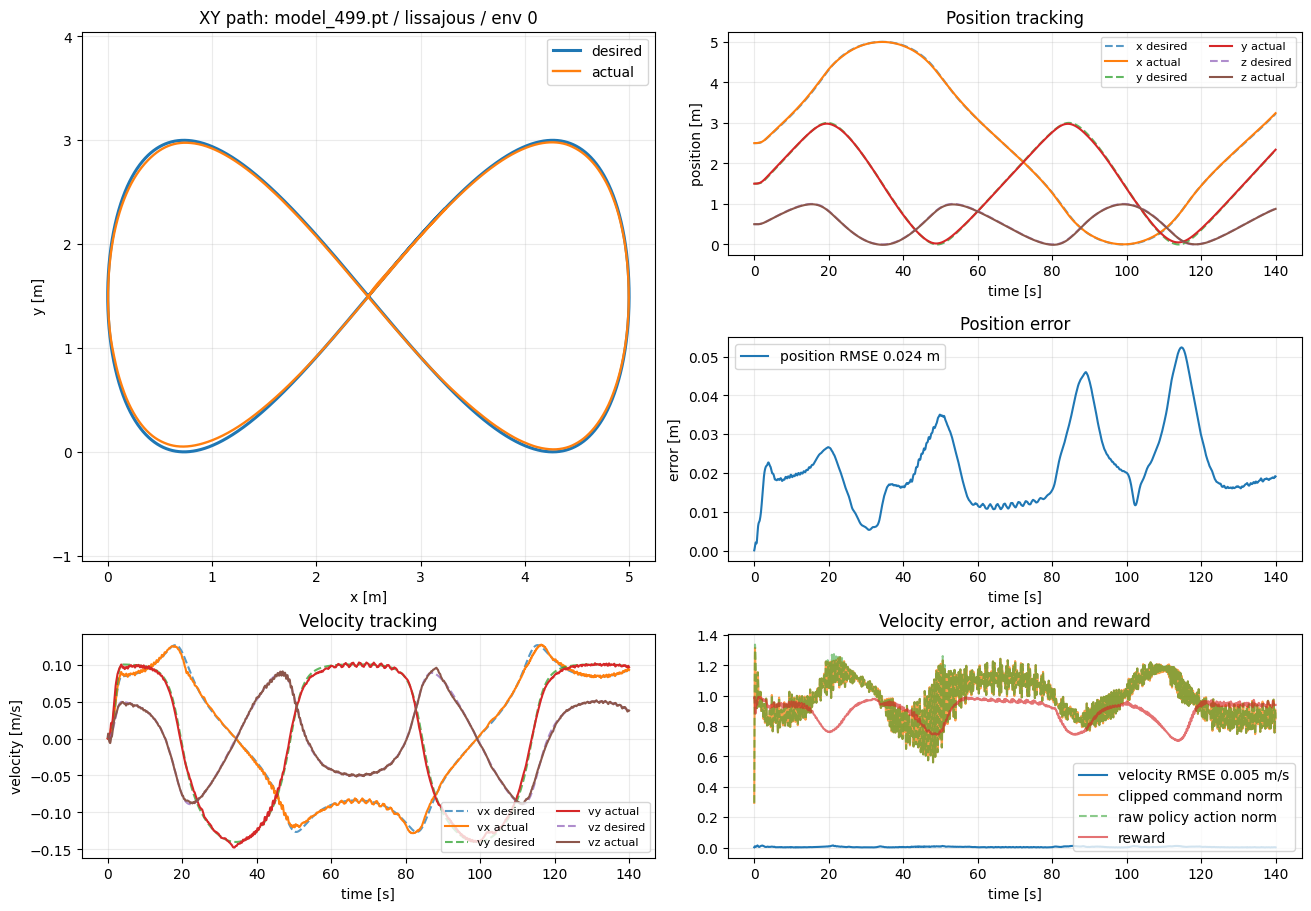

In [3]:
summary_df = collect_summary_df(SPEC, ACTIVE_RUN, case_label=EVALUATION_LABEL)
summary_df = summary_df[
    (summary_df['checkpoint_name'] == CHECKPOINT)
    & (summary_df['trajectory'] == TRAJECTORY)
].copy()
display(summary_df[[
    'checkpoint_name', 'position_rmse', 'steady_position_rmse',
    'steady_position_error_p95', 'steady_position_bias_norm_m',
    'steady_position_x_rmse_m', 'steady_position_y_rmse_m',
    'steady_position_z_rmse_m', 'steady_cross_track_position_error_rmse_m',
    'steady_attitude_error_rmse_deg', 'steady_mean_nose_to_target_heading_angle_deg',
    'mean_thruster_wrench_force_norm_n', 'minimum_vehicle_boundary_clearance_m',
    'mean_reward_per_step',
]])
display(quick_numeric_report(summary_df))

detail_df, detail_path = load_eval_log(
    SPEC, ACTIVE_RUN, CHECKPOINT, TRAJECTORY, EVALUATION_LABEL,
)
print(f'loaded {len(detail_df)} time-aligned rows from {detail_path}')
detail_figure = plot_eval_detail(
    SPEC, ACTIVE_RUN, detail_df, CHECKPOINT, TRAJECTORY,
    case_label=EVALUATION_LABEL, env_id=0, save=True,
)
display(detail_figure)
plt.close(detail_figure)
